In [141]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pickle
print("Import Successful!")

Import Successful!


In [3]:
data = pd.read_csv(r"C:\Users\sharm\Desktop\Dataset\HousePricePrediction.csv")

In [4]:
df = data.copy()

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [6]:
df.shape

(2919, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [8]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [9]:
num_cols = df.select_dtypes(include = "number")
cat_cols = df.select_dtypes(include = ["category", "object"])


In [10]:
df.drop("Id", axis = 1)

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [11]:
df["LotConfig"].unique()

array(['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3'], dtype=object)

# Handling Missing values

In [12]:
df.isna().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [18]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns


In [19]:
num_imputer = SimpleImputer(strategy="median")

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [20]:
df["MSZoning"].fillna(df["MSZoning"].mode(), inplace = True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   float64
 1   MSSubClass    2919 non-null   float64
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   float64
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   float64
 7   YearBuilt     2919 non-null   float64
 8   YearRemodAdd  2919 non-null   float64
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2919 non-null   float64
 11  TotalBsmtSF   2919 non-null   float64
 12  SalePrice     2919 non-null   float64
dtypes: float64(9), object(4)
memory usage: 296.6+ KB


# EDA

In [25]:
num_cols

Index(['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice'],
      dtype='object')

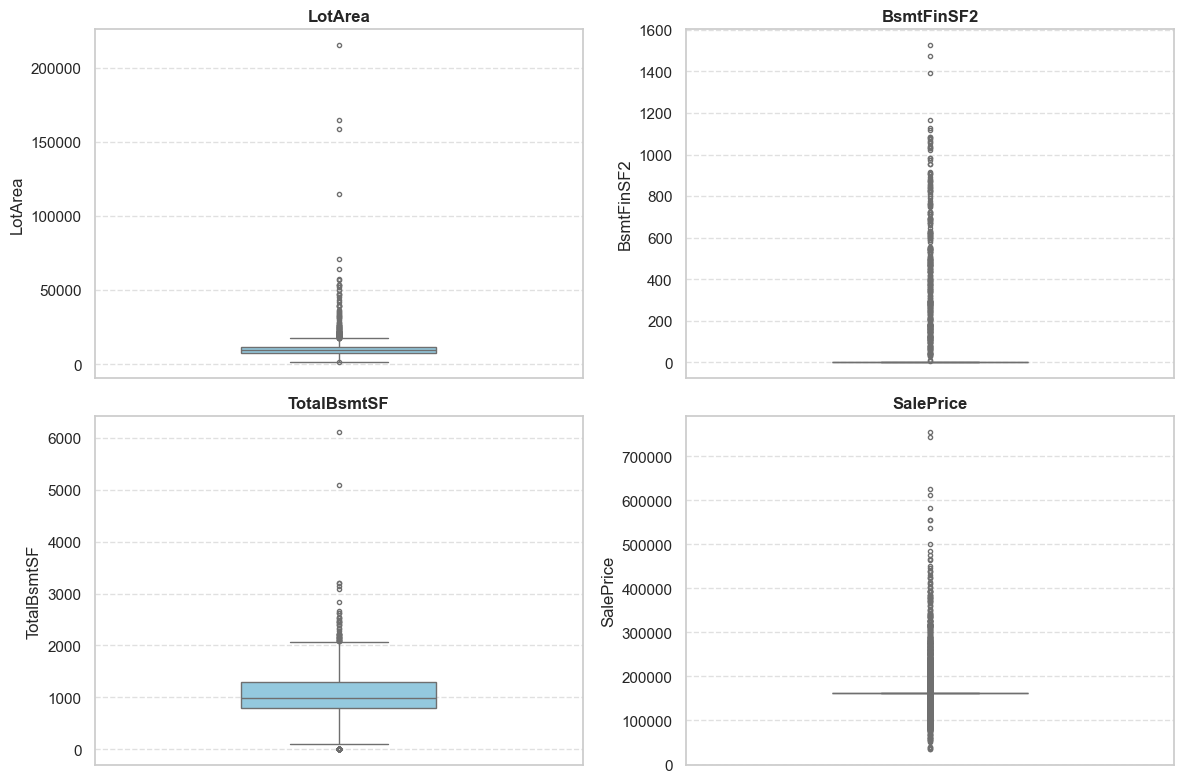

In [28]:
sns.set_theme(style="whitegrid")

cols = ["LotArea", "BsmtFinSF2", "TotalBsmtSF", "SalePrice"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color="skyblue",
        width=0.4,
        fliersize=3
    )
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

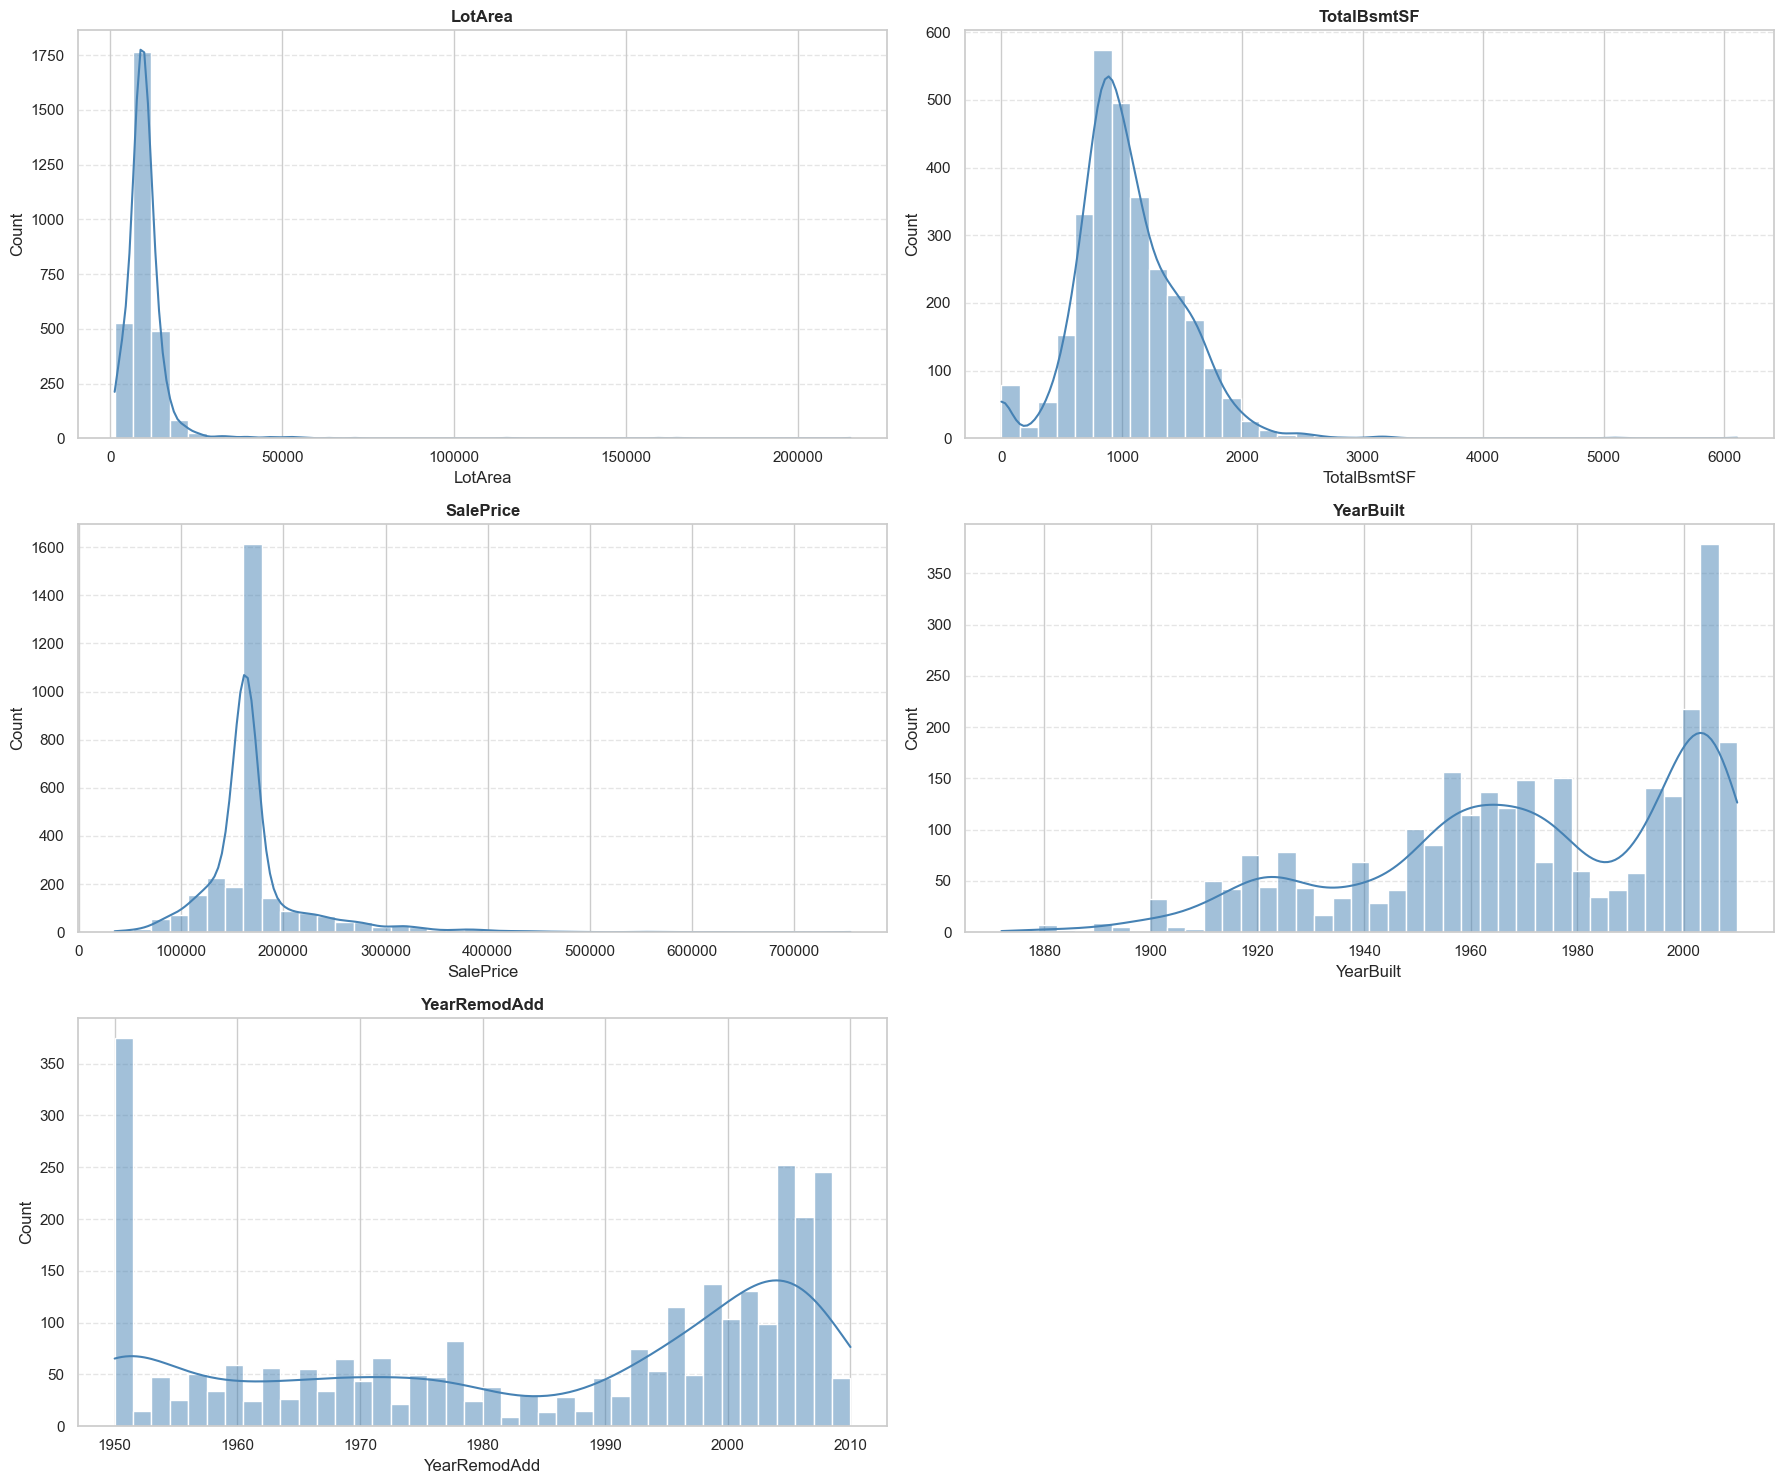

In [34]:
fig, axes = plt.subplots(3,2, figsize=(18, 15))
axes = axes.flatten()

hist_cols = ["LotArea", "TotalBsmtSF", "SalePrice", "YearBuilt", "YearRemodAdd"]

for i, col in enumerate(hist_cols):
    sns.histplot(
        df[col],
        bins=40,
        kde=True,
        ax=axes[i],
        color="steelblue"
    )
    axes[i].set_title(col, fontweight="bold")
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

for j in range(len(hist_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [48]:
skewed_cols = ["LotArea", "TotalBsmtSF", "SalePrice", "BsmtFomSF2"]

for col in cols:
    df[col + "_log"] = np.log1p(df[col])


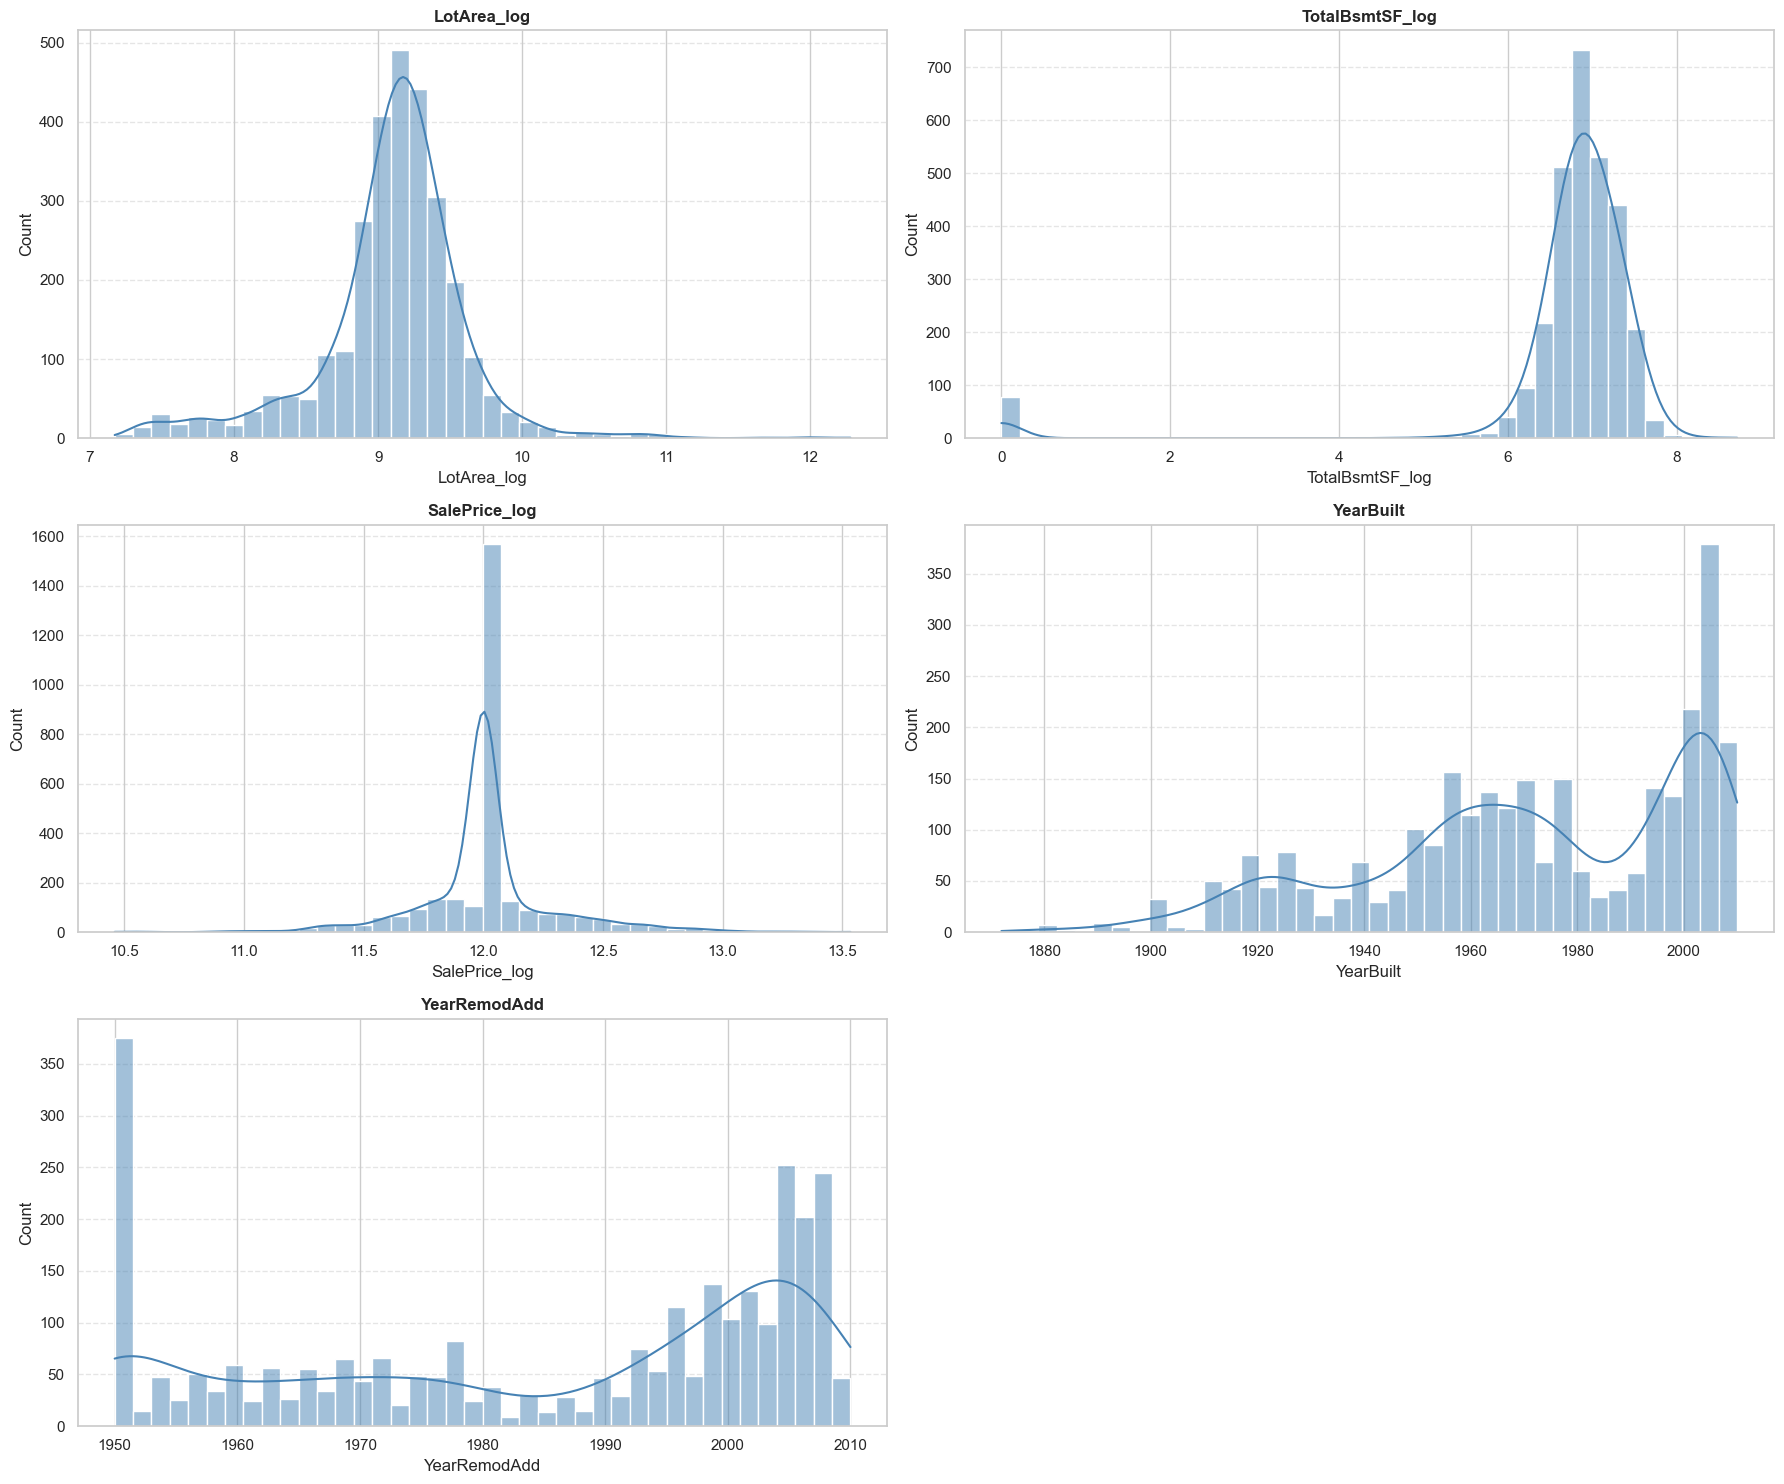

In [41]:
fig, axes = plt.subplots(3,2, figsize=(18, 15))
axes = axes.flatten()

hist_cols = ["LotArea_log", "TotalBsmtSF_log", "SalePrice_log", "YearBuilt", "YearRemodAdd"]

for i, col in enumerate(hist_cols):
    sns.histplot(
        df[col],
        bins=40,
        kde=True,
        ax=axes[i],
        color="steelblue"
    )
    axes[i].set_title(col, fontweight="bold")
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

for j in range(len(hist_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [51]:
df.drop(
    ["Id", "LotArea", "TotalBsmtSF", "SalePrice", "BsmtFinSF2"],
    axis=1,
    inplace=True
)


In [52]:
df

,MSSubClass,MSZoning,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,LotArea_log,TotalBsmtSF_log,BsmtFinSF2_log,SalePrice_log
0,60.0,RL,Inside,1Fam,5.0,2003.0,2003.0,VinylSd,9.042040,6.753438,0.0,12.247699
1,20.0,RL,FR2,1Fam,8.0,1976.0,1976.0,MetalSd,9.169623,7.141245,0.0,12.109016
2,60.0,RL,Inside,1Fam,5.0,2001.0,2002.0,VinylSd,9.328212,6.825460,0.0,12.317171
3,70.0,RL,Corner,1Fam,5.0,1915.0,1970.0,Wd Sdng,9.164401,6.629363,0.0,11.849405
4,60.0,RL,FR2,1Fam,5.0,2000.0,2000.0,VinylSd,9.565284,7.044033,0.0,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...
2914,160.0,RM,Inside,Twnhs,7.0,1970.0,1970.0,CemntBd,7.568896,6.304449,0.0,12.001512
2915,160.0,RM,Inside,TwnhsE,5.0,1970.0,1970.0,CemntBd,7.546974,6.304449,0.0,12.001512
2916,20.0,RL,Inside,1Fam,7.0,1960.0,1996.0,VinylSd,9.903538,7.110696,0.0,12.001512
2917,85.0,RL,Inside,1Fam,5.0,1992.0,1992.0,HdBoard,9.253591,6.816736,0.0,12.001512


In [53]:
num_df = df.select_dtypes(include = ['int64', 'float64'])
corr = num_df.corr()

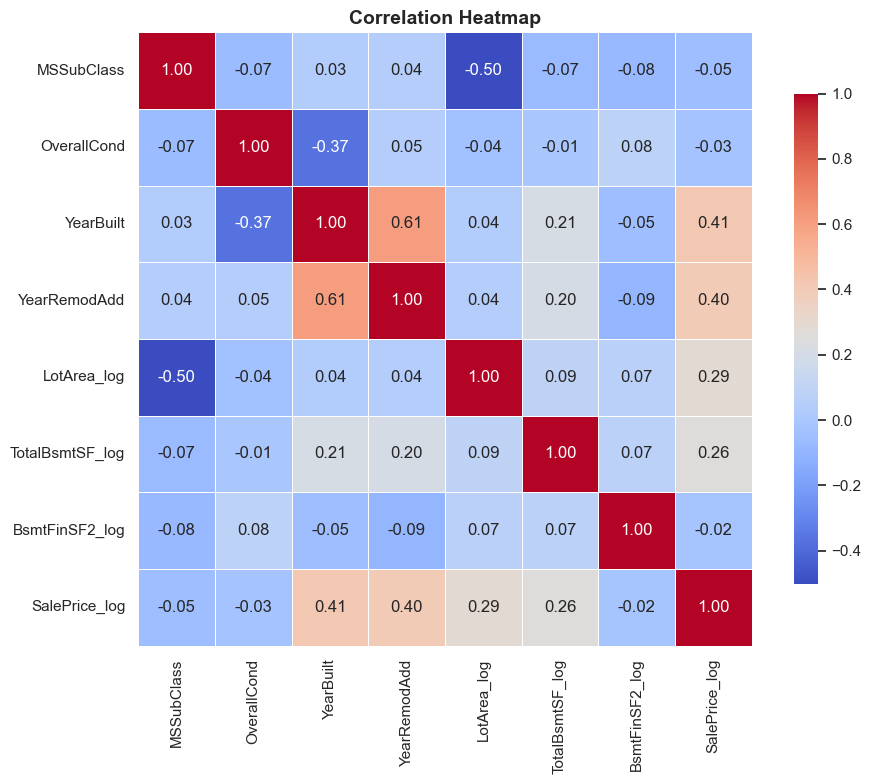

In [57]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("house.png")
plt.show()

In [58]:
df.drop("BsmtFinSF2_log", axis = 1, inplace = True)

In [60]:
df.head()

,MSSubClass,MSZoning,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,LotArea_log,TotalBsmtSF_log,SalePrice_log
0,60.0,RL,Inside,1Fam,5.0,2003.0,2003.0,VinylSd,9.042040,6.753438,12.247699
1,20.0,RL,FR2,1Fam,8.0,1976.0,1976.0,MetalSd,9.169623,7.141245,12.109016
2,60.0,RL,Inside,1Fam,5.0,2001.0,2002.0,VinylSd,9.328212,6.825460,12.317171
3,70.0,RL,Corner,1Fam,5.0,1915.0,1970.0,Wd Sdng,9.164401,6.629363,11.849405
4,60.0,RL,FR2,1Fam,5.0,2000.0,2000.0,VinylSd,9.565284,7.044033,12.429220


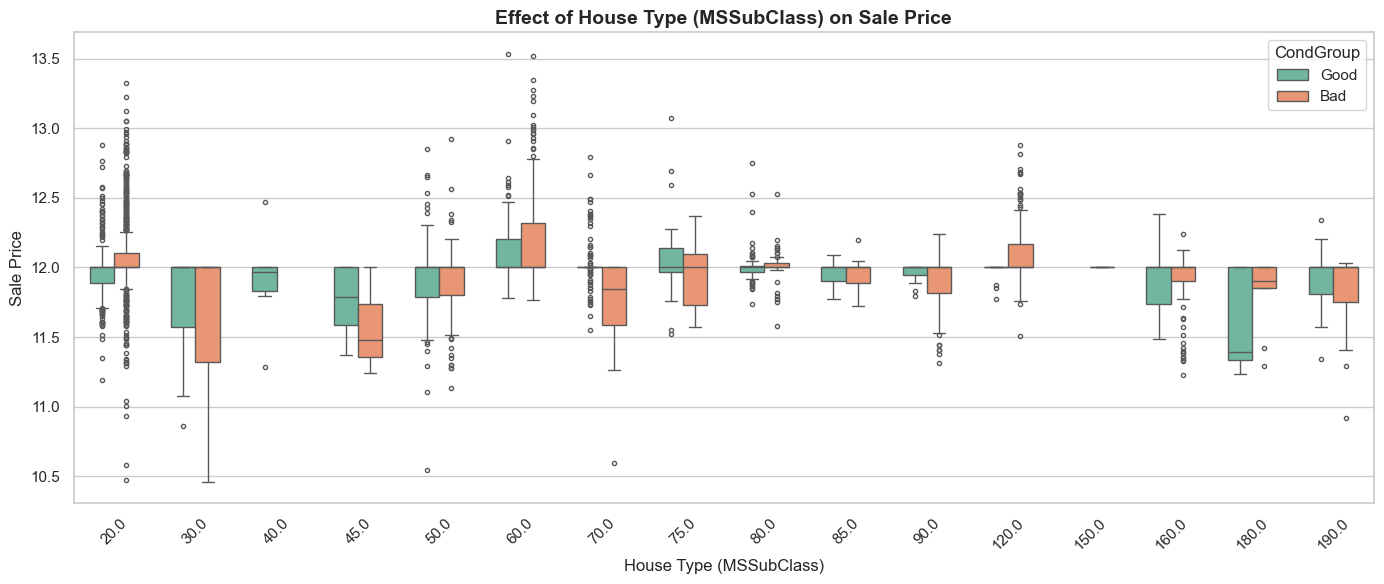

In [65]:
df["CondGroup"] = df["OverallCond"].apply(
    lambda x: "Good" if x >= 6 else "Bad"
)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))

sns.boxplot(
    x="MSSubClass",
    y="SalePrice_log",
    data=df,
    hue = "CondGroup",
    palette="Set2",
    width=0.6,
    fliersize=3
)

plt.title(
    "Effect of House Type (MSSubClass) on Sale Price",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("House Type (MSSubClass)")
plt.ylabel("Sale Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [67]:
# interaction term
df["Cond_x_MSSubClass"] = df["OverallCond"] * df["MSSubClass"]
df.drop(["OverallCond", "MSSubClass"], axis = 1, inplace = True)

# Train test split

In [82]:
X = df.drop(["SalePrice", "SalePrice_log"], axis=1)
y = df["SalePrice_log"]

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [91]:
scaler = StandardScaler()

num_cols = [
    "YearBuilt",
    "YearRemodAdd",
    "LotArea_log",
    "TotalBsmtSF_log",
    "Cond_x_MSSubClass"
]


X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])

In [92]:
X_train[num_cols].mean()


YearBuilt            9.129029e-18
YearRemodAdd        -6.086019e-18
LotArea_log         -3.043010e-18
TotalBsmtSF_log     -6.086019e-18
Cond_x_MSSubClass   -4.564514e-18
dtype: float64

In [93]:
X_train[num_cols].std()

YearBuilt            1.000214
YearRemodAdd         1.000214
LotArea_log          1.000214
TotalBsmtSF_log      1.000214
Cond_x_MSSubClass    1.000214
dtype: float64

In [102]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [103]:
y_pred = lr.predict(X_test)

In [115]:
print("mean sq error>> \n", mean_squared_error(y_test, y_pred))
print("R sq error>> \n", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

mean sq error>> 
 0.061850972723049145
R sq error>> 
 0.3442986858520115
RMSE: 0.2486985579432441


In [120]:
ridge = Ridge(alpha = 10.0)

ridge.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [121]:
y_pred_ridge = ridge.predict(X_test)
print("mean sq error>> \n", mean_squared_error(y_test, y_pred_ridge))
print("R sq error>> \n", r2_score(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

mean sq error>> 
 0.0621167048850475
R sq error>> 
 0.3414815769180274
RMSE: 0.24923223083110158


# pipeline and pickle

In [125]:
num_cols = [
    "LotArea_log",
    "TotalBsmtSF_log",
    "YearBuilt",
    "YearRemodAdd"
]

cat_cols = [
    "MSZoning",
    "LotConfig",
    "BldgType",
    "Exterior1st",
    "CondGroup"
]

In [128]:
num_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])


In [129]:
cat_pipeline = Pipeline([
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [131]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [132]:
model = Pipeline([
    ("preprocess", preprocessor),
    ("ridge", Ridge(alpha=10.0))
])

In [139]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [140]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.2503535485924485
R2: 0.33554278253548686


C:\Users\sharm\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [142]:
with open("house_price_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [146]:
with open("house_price_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)


In [147]:
new_data = X_test.iloc[:5]   # or any new dataframe with same columns

pred_log = loaded_model.predict(new_data)
pred_price = np.expm1(pred_log)

print(pred_price)


[137455.77577149 168377.13257278 148446.26971788 172770.41266713
 181410.82108326]
